# Lasso Regression — Feature Selection Built Into the Fit

The previous notebooks selected features as a separate step: rank them, then refit. **Lasso** folds
selection into the fitting itself. By penalizing the sum of absolute coefficient values it drives
some coefficients to *exactly* zero, and a coefficient of zero is a feature removed.

We build it up twice — first with a single variable, where the penalty's effect can be seen
directly in the fitted line, then with fifteen, where it does real selection work.

## Learning objectives

- Write the Lasso objective and identify the role of the penalty strength $\alpha$
- Explain why an $L_1$ penalty produces exact zeros where $L_2$ only shrinks
- Sweep $\alpha$ and read the resulting score, error, and coefficient curves
- State why features must be standardized before Lasso with multiple predictors
- Compare a coefficient's magnitude against that feature's raw correlation with the target

## Background

This notebook assumes linear regression, $R^2$, MSE, and the train/test split from
`U1-3_Regression-1_ModelCompare`, and standardization from `U1-2_Preprocess`. The overfitting
curves have the same shape as `U1-3_Regression-2_Overfitting`, with $\alpha$ as the knob.

**Prerequisites:** `U1-2_Preprocess` (standardization),
`U1-3_Regression-1_ModelCompare` ($R^2$, MSE)

**Dataset:** none — a 1-D synthetic target in section 1 with three shapes available by toggling
comments, then a 15-feature `make_regression` dataset in section 2.

**References:** https://scikit-learn.org/stable/modules/linear_model.html#lasso

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Lasso with one variable

### 1.1 Create the data

Three targets are provided, one commented in at a time, and each says something different about what
a penalized *linear* model can do:

| Option | Target | What it shows |
|---|---|---|
| Line (active) | $y = x + \varepsilon$ | The case Lasso is built for. The unpenalized fit is correct, so any shrinkage is pure damage — which makes the cost of $\alpha$ easy to see. |
| Parabola | $y = 0.3x^2 + \varepsilon$ | A linear model cannot fit this at any $\alpha$. Underfitting and over-penalization look similar; worth seeing so they can be told apart. |
| Sine | $y = \sin(x) + \varepsilon$ | Same lesson, more extreme — over $x \in [-3,3]$ the best straight line is nearly flat before any penalty is applied. |

All three use $\varepsilon \sim \mathcal{N}(0, 0.3^2)$.

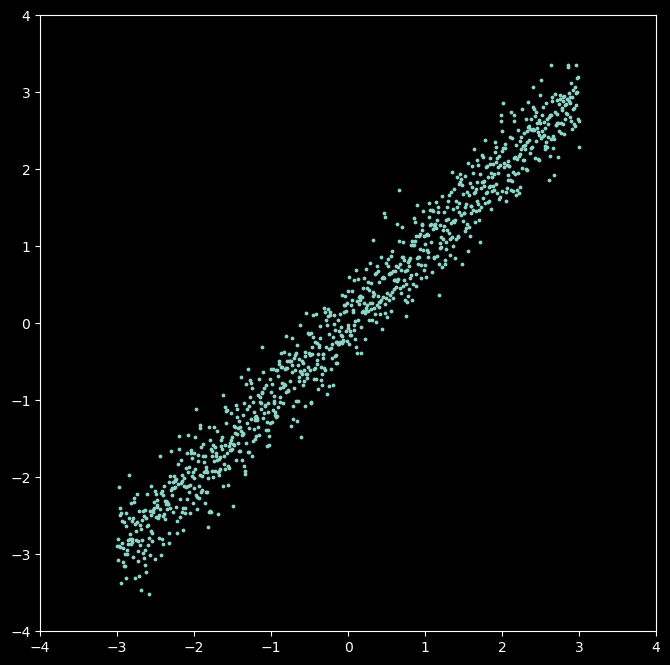

In [2]:
nPts = 1000

m = 1
b = 0

x = np.linspace(-3, 3, nPts)
y = m*x + b + np.random.normal(0, 0.3, nPts)
#y = 0.3*x**2 + np.random.normal(0, 0.3, nPts)
#y = np.sin(x) + np.random.normal(0, 0.3, nPts)

X = x[:,np.newaxis]

plt.figure(figsize=(8,8))
plt.scatter(x, y, label='Data', s=3);
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.gca().set_aspect('equal')

### 1.2 Fit at a single $\alpha$

Lasso minimizes squared error **plus** a penalty on the size of the coefficients:

$$\hat{\beta} = \arg\min_{\beta} \; \frac{1}{2n}\lVert y - X\beta \rVert_2^2 \;+\; \alpha \lVert \beta \rVert_1,
\qquad \lVert \beta \rVert_1 = \sum_j |\beta_j|$$

At $\alpha = 0$ this is ordinary least squares. As $\alpha$ grows, coefficients are pulled toward
zero, and — unlike Ridge, which uses $\lVert\beta\rVert_2^2$ and only shrinks — the $L_1$ penalty
sets them to **exactly** zero once $\alpha$ is large enough.

The geometric reason: the $L_1$ constraint region is a diamond with corners **on** the axes, and a
corner is where a coefficient is exactly zero. The $L_2$ region is a circle with no corners, so its
solution almost never lands exactly on an axis.

$\alpha = 10$ is deliberately large here. Look at the prediction line in the plot below and at the
error — with the coefficient driven to zero, the model predicts a constant, and the "fit" is a
horizontal line at the mean of $y$.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, y_pred)

3.2697560108835444

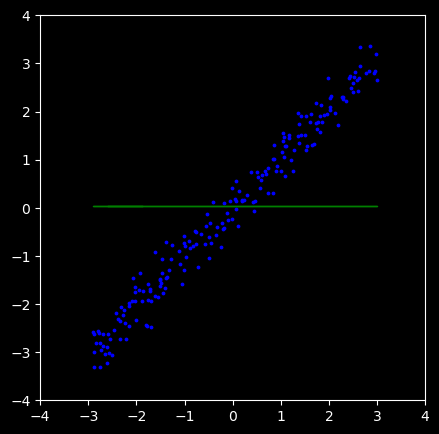

In [6]:
plt.figure(figsize=(5,5))
plt.scatter(X_test, y_test, color='b', s=3);
plt.plot(X_test, y_pred, 'g', linewidth=1);
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.gca().set_aspect('equal')

### 1.3 Varying $\alpha$

Sweep $\alpha$ from 0 to 10 and record $R^2$, MSE, and the coefficient at each value.

With one genuinely useful predictor there is nothing to select, so this sweep shows the penalty's
cost with none of its benefit: performance is best at $\alpha = 0$ and degrades from there, and the
coefficient slides to zero. Section 2 supplies the other half of the picture.

In [7]:
from sklearn.metrics import r2_score, mean_squared_error

# Define alpha values
alphas = np.linspace(0, 10, 100)

# Initialize storage arrays
r2s_train = []
r2s_test  = []
mse_train = []
mse_test  = []
coefs     = []

for a in alphas:
    model = Lasso(alpha=a)  # Switch to Ridge(alpha=a) if needed

    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Compute R² scores
    r2s_train.append(r2_score(y_train, y_train_pred))
    r2s_test.append(r2_score(y_test, y_test_pred))
    
    # Compute MSE
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))

    # Store coefficients
    coefs.append(model.coef_)
# end

# Convert to NumPy arrays for efficient computation
r2s_train = np.array(r2s_train)
r2s_test  = np.array(r2s_test)
mse_train = np.array(mse_train)
mse_test  = np.array(mse_test)
coefs     = np.array(coefs)

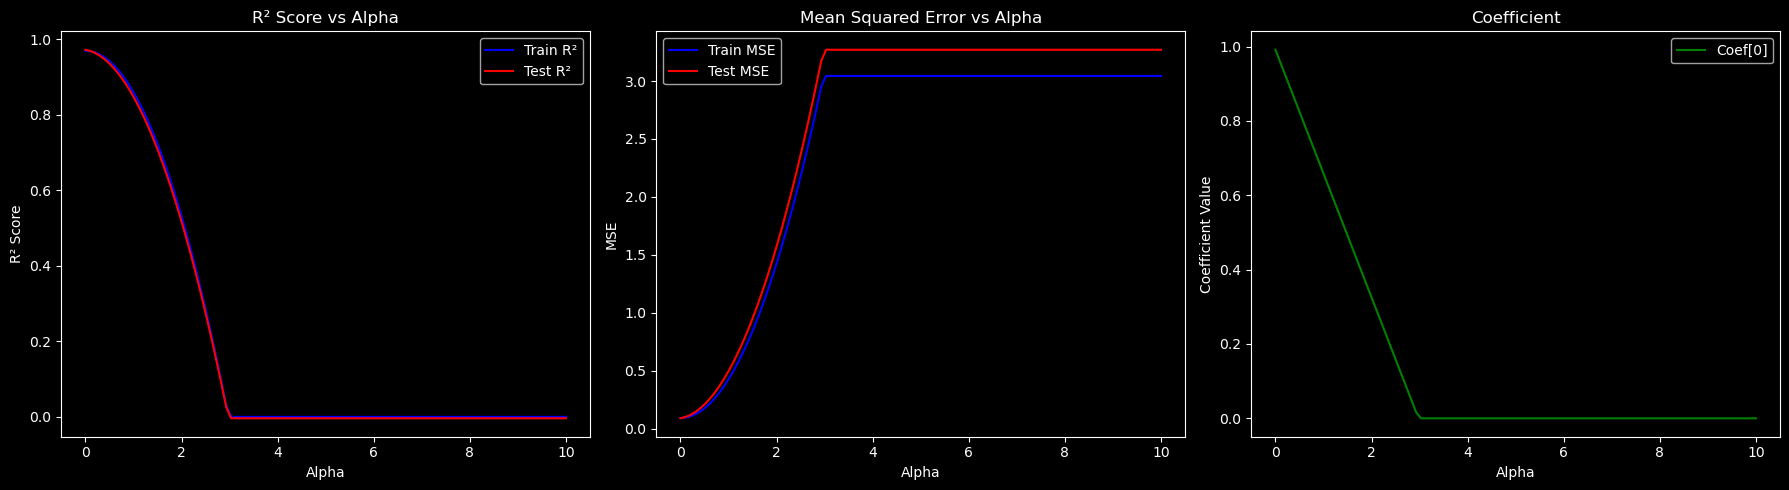

In [8]:
# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot R² scores (Train vs. Test)
axes[0].plot(alphas, r2s_train, 'b', label="Train R²")
axes[0].plot(alphas, r2s_test, 'r', label="Test R²")
axes[0].set_title("R² Score vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R² Score")
axes[0].legend()

# Plot MSE values (Train vs. Test)
axes[1].plot(alphas, mse_train, 'b', label="Train MSE")
axes[1].plot(alphas, mse_test, 'r', label="Test MSE")
axes[1].set_title("Mean Squared Error vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("MSE")
axes[1].legend()

# Plot first feature's coefficients across alpha values
axes[2].plot(alphas, coefs[:, 0], 'g', label="Coef[0]")
axes[2].set_title("Coefficient")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Coefficient Value")
axes[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

## 2. Lasso with many variables

### 2.1 Create the data

Fifteen features and heavy noise (`noise=125`). `make_regression` uses only some of them to build
$y$, so now there is something for the penalty to discard.

### 2.2 Standardize first — this is not optional

The penalty $\alpha\sum_j |\beta_j|$ treats every coefficient identically, but a coefficient's
*size* depends on its feature's units. A feature measured in thousands needs a coefficient a
thousand times smaller to make the same contribution, so it is penalized a thousand times less. On
unstandardized data, Lasso preferentially eliminates whichever features happen to be measured in
small units — an artifact of the measurement scale, not of relevance.

Standardizing puts every feature on the same footing and makes the penalty mean what it appears to
mean.

In [9]:
from sklearn import datasets

n_feat = 15

X, y = datasets.make_regression(
    n_samples=1000,
    n_features=n_feat,
    noise=125
)

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 2.3 Coefficients against raw correlation

Fit at a single $\alpha$, then plot the fitted coefficients beside each feature's raw correlation
with $y$, and finally against each other.

The comparison is the point. A large $|\rho|$ means a feature is informative *on its own*; a large
$|\beta|$ means it is informative *given the others*. Those come apart when features are redundant —
two correlated features can both correlate strongly with $y$ while Lasso keeps only one and zeros
the other, because once the first is in the model the second adds nothing worth its penalty.

The cell also offers `Ridge(alpha=50)` as a commented alternative, and swapping it in is the
cleanest way to see the $L_1$/$L_2$ difference: Ridge shrinks the whole coefficient bar chart toward
zero while leaving every bar nonzero, where Lasso zeros a subset outright.

[ 0.00000000e+00  2.26597648e+01  1.97066019e+01  8.37620344e+01
  6.41969869e+01  9.26325725e+01  2.21090496e+00  3.07243729e+01
  3.04460418e+00  5.28600190e+01 -0.00000000e+00  0.00000000e+00
  2.10537178e-03  7.39542056e+01  7.50634598e+01]


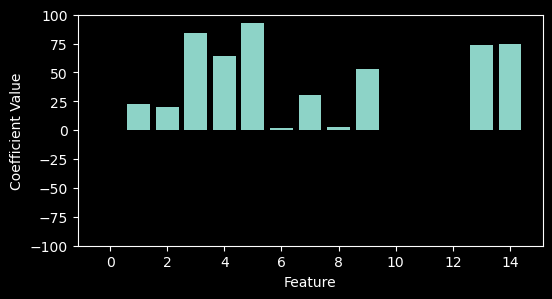

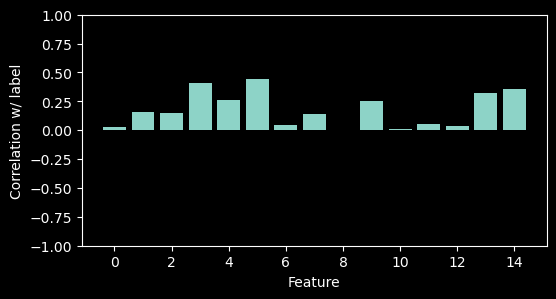

In [11]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

model = Lasso(alpha=5)
#model = Ridge(alpha=50)

model.fit(X_train, y_train)

coef = model.coef_
print(coef)

plt.figure(figsize=(6,3));
plt.bar(range(n_feat), coef);
plt.xlabel('Feature');
plt.ylabel('Coefficient Value');
plt.ylim(-100,100);
plt.show()

corr = []

for i in range(n_feat):
    corr.append( np.corrcoef(y,X[:,i])[0,1] )
# end

plt.figure(figsize=(6,3));
plt.bar(range(n_feat), corr);
plt.xlabel('Feature');
plt.ylabel('Correlation w/ label');
plt.ylim(-1,1);

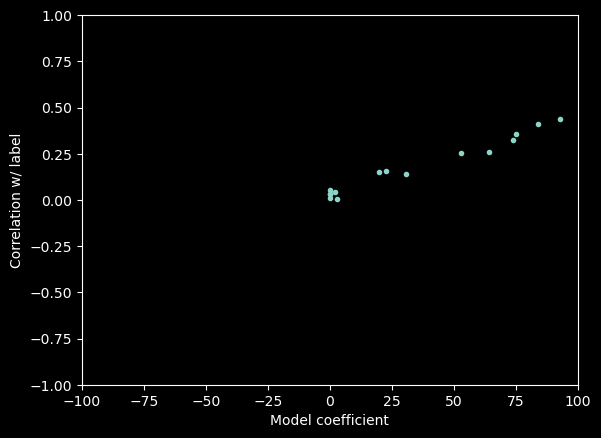

In [12]:
plt.plot( coef, corr, '.' )
plt.xlim(-100,100);
plt.ylim(-1,1);
plt.xlabel('Model coefficient');
plt.ylabel('Correlation w/ label');

### 2.4 Varying $\alpha$

The same sweep as section 1.3, now over 0 to 100 and additionally tracking the **number of nonzero
coefficients** — the count of features Lasso has chosen to keep.

Now the penalty earns its keep. Expect the test curve to *improve* before it degrades: some
shrinkage removes noise features and helps generalization, and only past the peak does it start
discarding real signal. That peak is the same structure as every other complexity sweep in this
unit, with $\alpha$ running in the opposite direction — larger $\alpha$ means a *simpler* model.

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

# Define alpha values
alphas = np.linspace(0, 100, 100)

# Initialize storage arrays
r2s_train = []
r2s_test  = []
mse_train = []
mse_test  = []
coefs     = []
non_zero  = []

for a in alphas:
    model = Lasso(alpha=a)  # Switch to Ridge(alpha=a) if needed

    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Compute R² scores
    r2s_train.append(r2_score(y_train, y_train_pred))
    r2s_test.append(r2_score(y_test, y_test_pred))
    
    # Compute MSE
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))

    # Store coefficients
    coefs.append(model.coef_)

    # Get number of non-zero coefficients
    non_zero.append( (model.coef_ != 0).sum() )
# end

# Convert to NumPy arrays for efficient computation
r2s_train = np.array(r2s_train)
r2s_test  = np.array(r2s_test)
mse_train = np.array(mse_train)
mse_test  = np.array(mse_test)
coefs     = np.array(coefs)
non_zero  = np.array(non_zero)

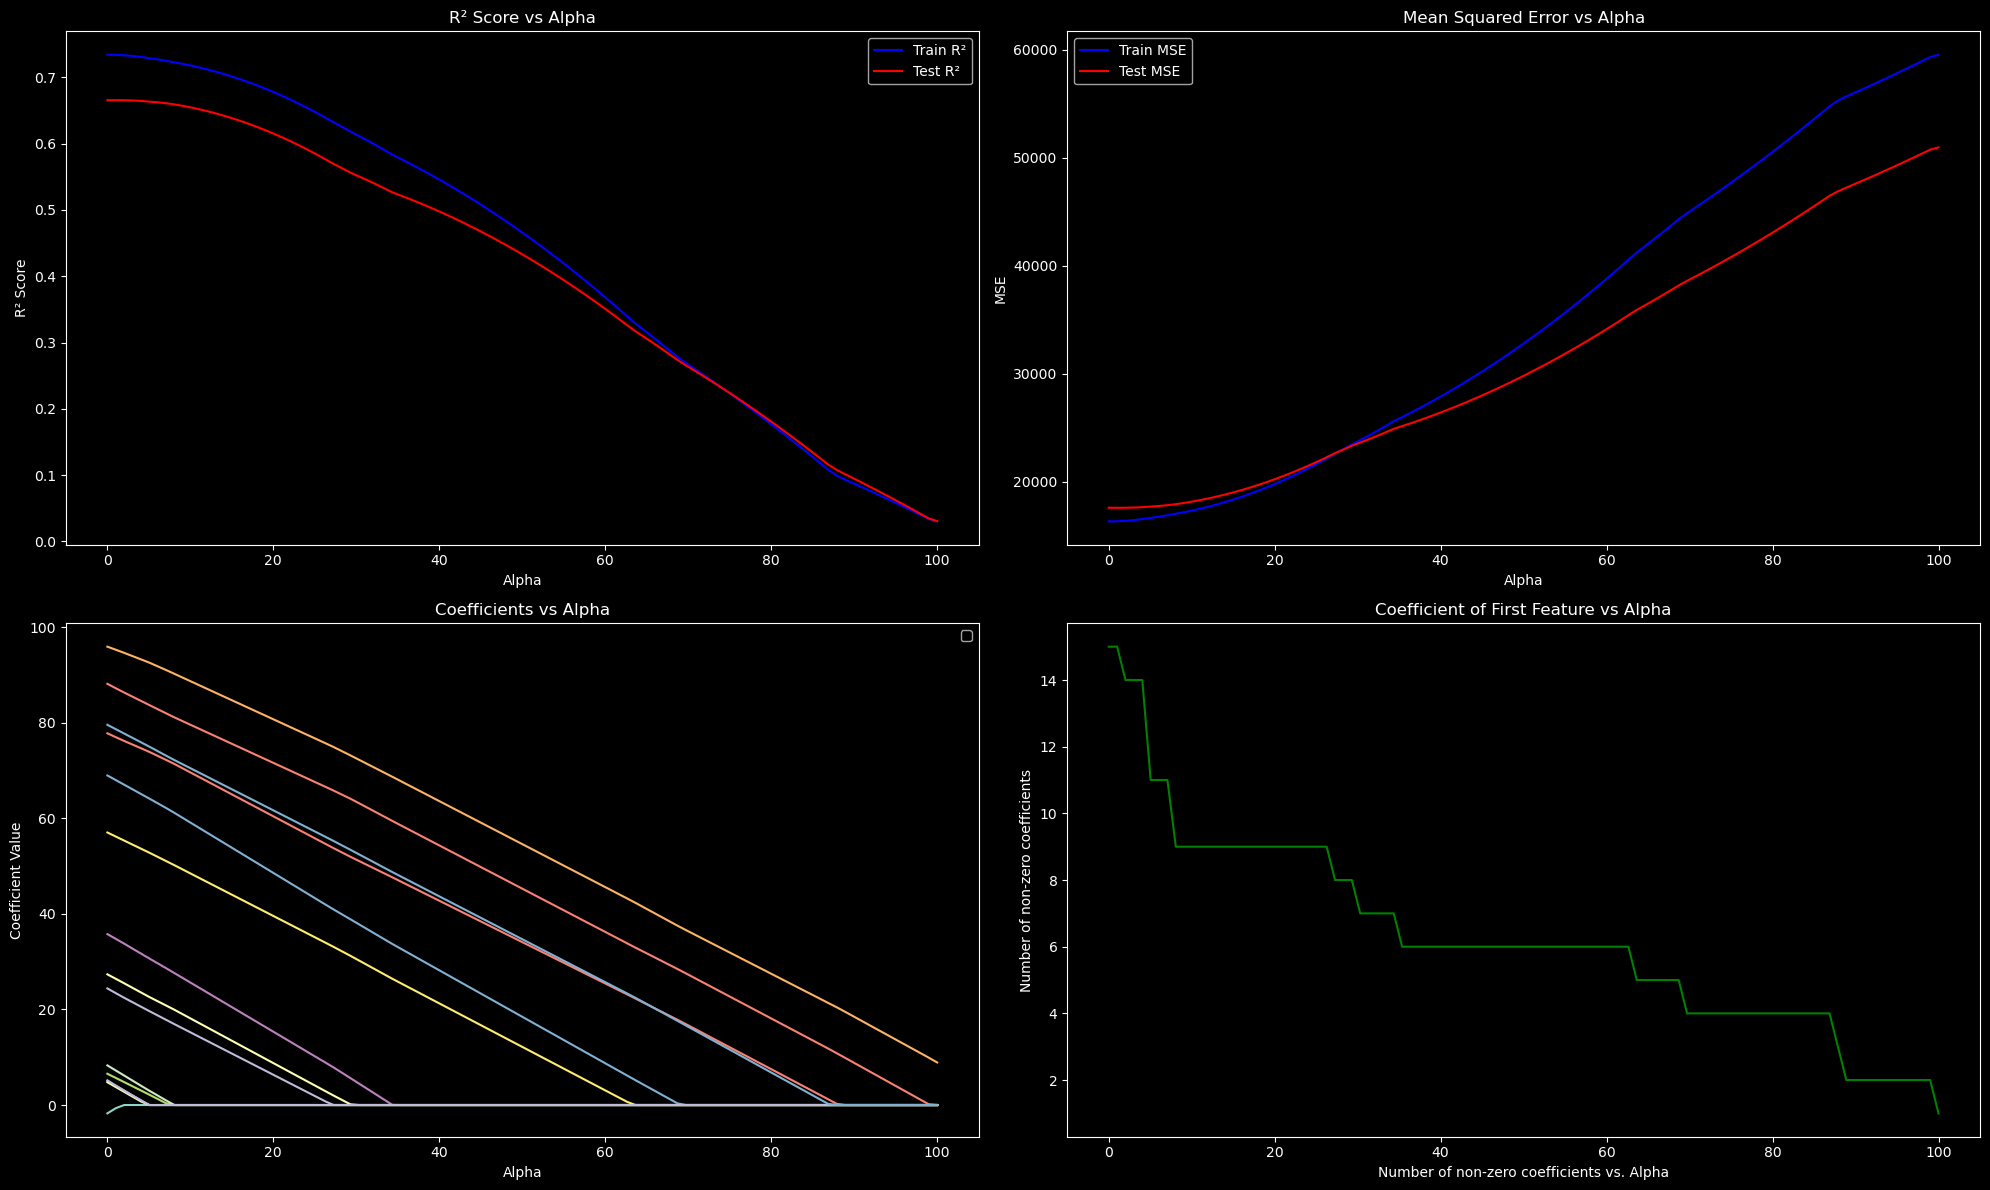

In [14]:
# Create figure with 3 subplots side by side
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# Plot R² scores (Train vs. Test)
axes[0].plot(alphas, r2s_train, 'b', label="Train R²")
axes[0].plot(alphas, r2s_test, 'r', label="Test R²")
axes[0].set_title("R² Score vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R² Score")
axes[0].legend()

# Plot MSE values (Train vs. Test)
axes[1].plot(alphas, mse_train, 'b', label="Train MSE")
axes[1].plot(alphas, mse_test, 'r', label="Test MSE")
axes[1].set_title("Mean Squared Error vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("MSE")
axes[1].legend()

# Plot first feature's coefficients across alpha values
for i in range(coefs.shape[1]):
    axes[2].plot( alphas, coefs[:,i] )
# end
axes[2].set_title("Coefficients vs Alpha")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Coefficient Value")
axes[2].legend()

# Plot first feature's coefficients across alpha values
axes[3].plot(alphas, non_zero, 'g', label="Coef[0]")
axes[3].set_title("Coefficient of First Feature vs Alpha")
axes[3].set_xlabel("Number of non-zero coefficients vs. Alpha")
axes[3].set_ylabel("Number of non-zero coefficients")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

The last cell pulls out the coefficient vector at the best test $R^2$ — the selected feature set,
read directly off the sweep.

In [15]:
coefs[np.argmax(r2s_test),:]

array([ 4.03420271, 26.4216163 , 23.41506384, 87.23816812, 68.0149159 ,
       95.2971746 ,  5.67292008, 34.78256566,  7.23063075, 56.19613185,
       -0.66563549,  3.76418426,  4.07990922, 76.99445208, 78.66958411])

## 3. Review

- **Lasso builds selection into the fit**, minimizing
  $\frac{1}{2n}\lVert y - X\beta\rVert_2^2 + \alpha\lVert\beta\rVert_1$.
- **$L_1$ zeros, $L_2$ shrinks.** The $L_1$ constraint region has corners on the axes; the $L_2$
  ball does not. A zeroed coefficient is a removed feature.
- **$\alpha$ is a complexity knob pointing backwards**: larger $\alpha$ means a simpler model. Its
  test curve peaks like every other complexity sweep in this unit.
- **With one good predictor the penalty is pure cost**; with many features and noise it improves
  generalization before it starts discarding signal.
- **Standardize before Lasso, always.** The penalty is scale-dependent, so unstandardized features
  are selected against by their units rather than their relevance.
- **Coefficient magnitude is not correlation.** $|\rho|$ measures a feature alone, $|\beta|$
  measures it given the others; redundant features make the two disagree.